In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet
import warnings
warnings.filterwarnings(action='ignore')

total_df = pd.read_csv('/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/data/seoul_real_estate.csv')
total_df["CTRT_DAY"] = pd.to_datetime(total_df["CTRT_DAY"], format="%Y-%m-%d")
types = list(total_df['BLDG_USG'].unique())
print(types)

['아파트', '오피스텔', '연립다세대', '단독다가구']


/Users/songsooyeoun/Desktop/git_test/streamlit/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
periods = 28 # 향후 28일간 예측을 한다고 설정

model = Prophet()
total_df2 = total_df.loc[total_df['BLDG_USG']==types[0], ['CTRT_DAY', 'THING_AMT']]
result_df = total_df2.groupby('CTRT_DAY')['THING_AMT'].agg('mean').reset_index()
result_df = result_df.rename(columns={'CTRT_DAY':'ds', 'THING_AMT':'y'})
model.fit(result_df)
future = model.make_future_dataframe(periods=periods)
forecast = model.predict(future)
forecast.tail()

16:50:44 - cmdstanpy - INFO - Chain [1] start processing
16:50:44 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
107,2025-04-21,79522.909957,60058.059565,98511.868240,75955.868000,82874.759775,-1046.305085,-1046.305085,-1046.305085,-1046.305085,-1046.305085,-1046.305085,0.0,0.0,0.0,78476.604872
108,2025-04-22,78484.309363,56808.510883,93354.151890,74701.229026,82022.682698,-2830.610441,-2830.610441,-2830.610441,-2830.610441,-2830.610441,-2830.610441,0.0,0.0,0.0,75653.698921
109,2025-04-23,77445.708769,56701.860846,93920.612422,73382.539721,81227.415770,-1371.560878,-1371.560878,-1371.560878,-1371.560878,-1371.560878,-1371.560878,0.0,0.0,0.0,76074.147891
110,2025-04-24,76407.108175,63736.101144,102527.396373,72120.015428,80423.091717,5588.410137,5588.410137,5588.410137,5588.410137,5588.410137,5588.410137,0.0,0.0,0.0,81995.518312
111,2025-04-25,75368.507581,55560.529143,93170.629175,70848.679269,79728.190652,-40.451505,-40.451505,-40.451505,-40.451505,-40.451505,-40.451505,0.0,0.0,0.0,75328.056075


16:50:47 - cmdstanpy - INFO - Chain [1] start processing
16:50:47 - cmdstanpy - INFO - Chain [1] done processing
16:50:48 - cmdstanpy - INFO - Chain [1] start processing
16:50:48 - cmdstanpy - INFO - Chain [1] done processing
16:50:48 - cmdstanpy - INFO - Chain [1] start processing
16:50:48 - cmdstanpy - INFO - Chain [1] done processing
16:50:48 - cmdstanpy - INFO - Chain [1] start processing
16:50:48 - cmdstanpy - INFO - Chain [1] done processing


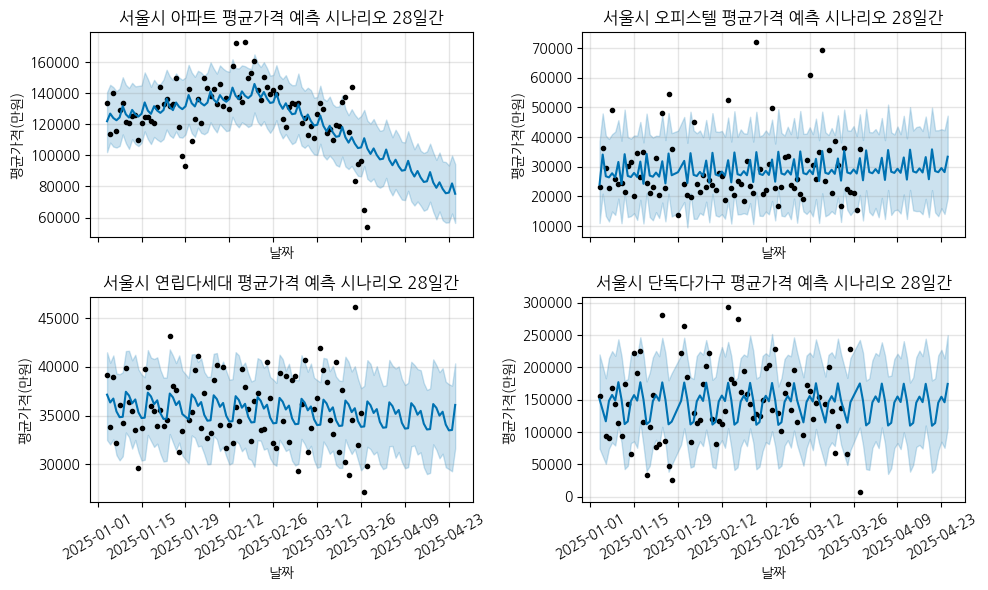

In [3]:
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = "NanumGothic"


fig, ax = plt.subplots(figsize=(10, 6), sharex=True, ncols=2, nrows=2)

for i in range(len(types)):
    model = Prophet()

    # Filter and aggregate data
    total_df2 = total_df[total_df['BLDG_USG'] == types[i]][['CTRT_DAY', 'THING_AMT']]
    result_df = total_df2.groupby('CTRT_DAY')['THING_AMT'].mean().reset_index()
    result_df = result_df.rename(columns={'CTRT_DAY': 'ds', 'THING_AMT': 'y'})

    model.fit(result_df)
    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    # Proper subplot indexing
    row, col = divmod(i, 2)
    model.plot(forecast, ax=ax[row, col], uncertainty=True)

    ax[row, col].set_title(f"서울시 {types[i]} 평균가격 예측 시나리오 {periods}일간")
    ax[row, col].set_xlabel("날짜")
    ax[row, col].set_ylabel("평균가격(만원)")
    for tick in ax[row, col].get_xticklabels():
        tick.set_rotation(30)

plt.tight_layout()
plt.show()

In [6]:
from prophet import Prophet
from prophet.serialize import model_to_json
import json

total_df = pd.read_csv('/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/data/seoul_real_estate_en.csv')
total_df["CTRT_DAY"] = pd.to_datetime(total_df["CTRT_DAY"], format="%Y-%m-%d")
total_df = total_df[total_df['BLDG_USG'] =='Apartment']

cgg_nms = sorted(list(total_df['CGG_NM'].unique()))
periods = 28 # 향후 28일간 예측을 한다고 설정

for cgg_nm in cgg_nms:
    model = Prophet()
    total_df2 = total_df.loc[total_df['CGG_NM']==cgg_nm, ['CTRT_DAY', 'THING_AMT']]
    summary_df = total_df2.groupby('CTRT_DAY')['THING_AMT'].agg('mean').reset_index()
    summary_df = summary_df.rename(columns={'CTRT_DAY':'ds', 'THING_AMT':'y'})
    model.fit(summary_df)
                
    with open(f'/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/en/ml/model/{cgg_nm}.model.json', 'w') as fout:
        json.dump(model_to_json(model), fout)

16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:58 - cmdstanpy - INFO - Chain [1] done processing
16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:58 - cmdstanpy - INFO - Chain [1] done processing
16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:58 - cmdstanpy - INFO - Chain [1] done processing
16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:58 - cmdstanpy - INFO - Chain [1] done processing
16:51:58 - cmdstanpy - INFO - Chain [1] start processing
16:51:58 - cmdstanpy - INFO - Chain [1] done processing
16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing
16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing
16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1] done processing
16:51:59 - cmdstanpy - INFO - Chain [1] start processing
16:51:59 - cmdstanpy - INFO - Chain [1]

In [12]:
from prophet.serialize import model_from_json

models = []

for cgg_nm in cgg_nms:
    print(cgg_nm)
    with open(f'/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/ml/model/{cgg_nm}.model.json', 'r') as fin:
        model = model_from_json(json.load(fin))
    models.append(model)
models

강남구
강동구
강북구
강서구
관악구
광진구
구로구
금천구
노원구
도봉구
동대문구
동작구
마포구
서대문구
서초구
성동구
성북구
송파구
양천구
영등포구
용산구
은평구
종로구
중구
중랑구


In [25]:
# 예측된 데이터에서 미래값만 추

start_date = forecast[forecast['ds'] > summary_df['ds'].max()]['ds'].min()
end_date = forecast[forecast['ds'] > summary_df['ds'].max()]['ds'].max()

print(start_date, end_date)

2025-03-27 00:00:00 2025-04-22 00:00:00


In [20]:
forecast['ds'].min()

Timestamp('2025-01-04 00:00:00')

## 전체 자치구별 모델 시각화

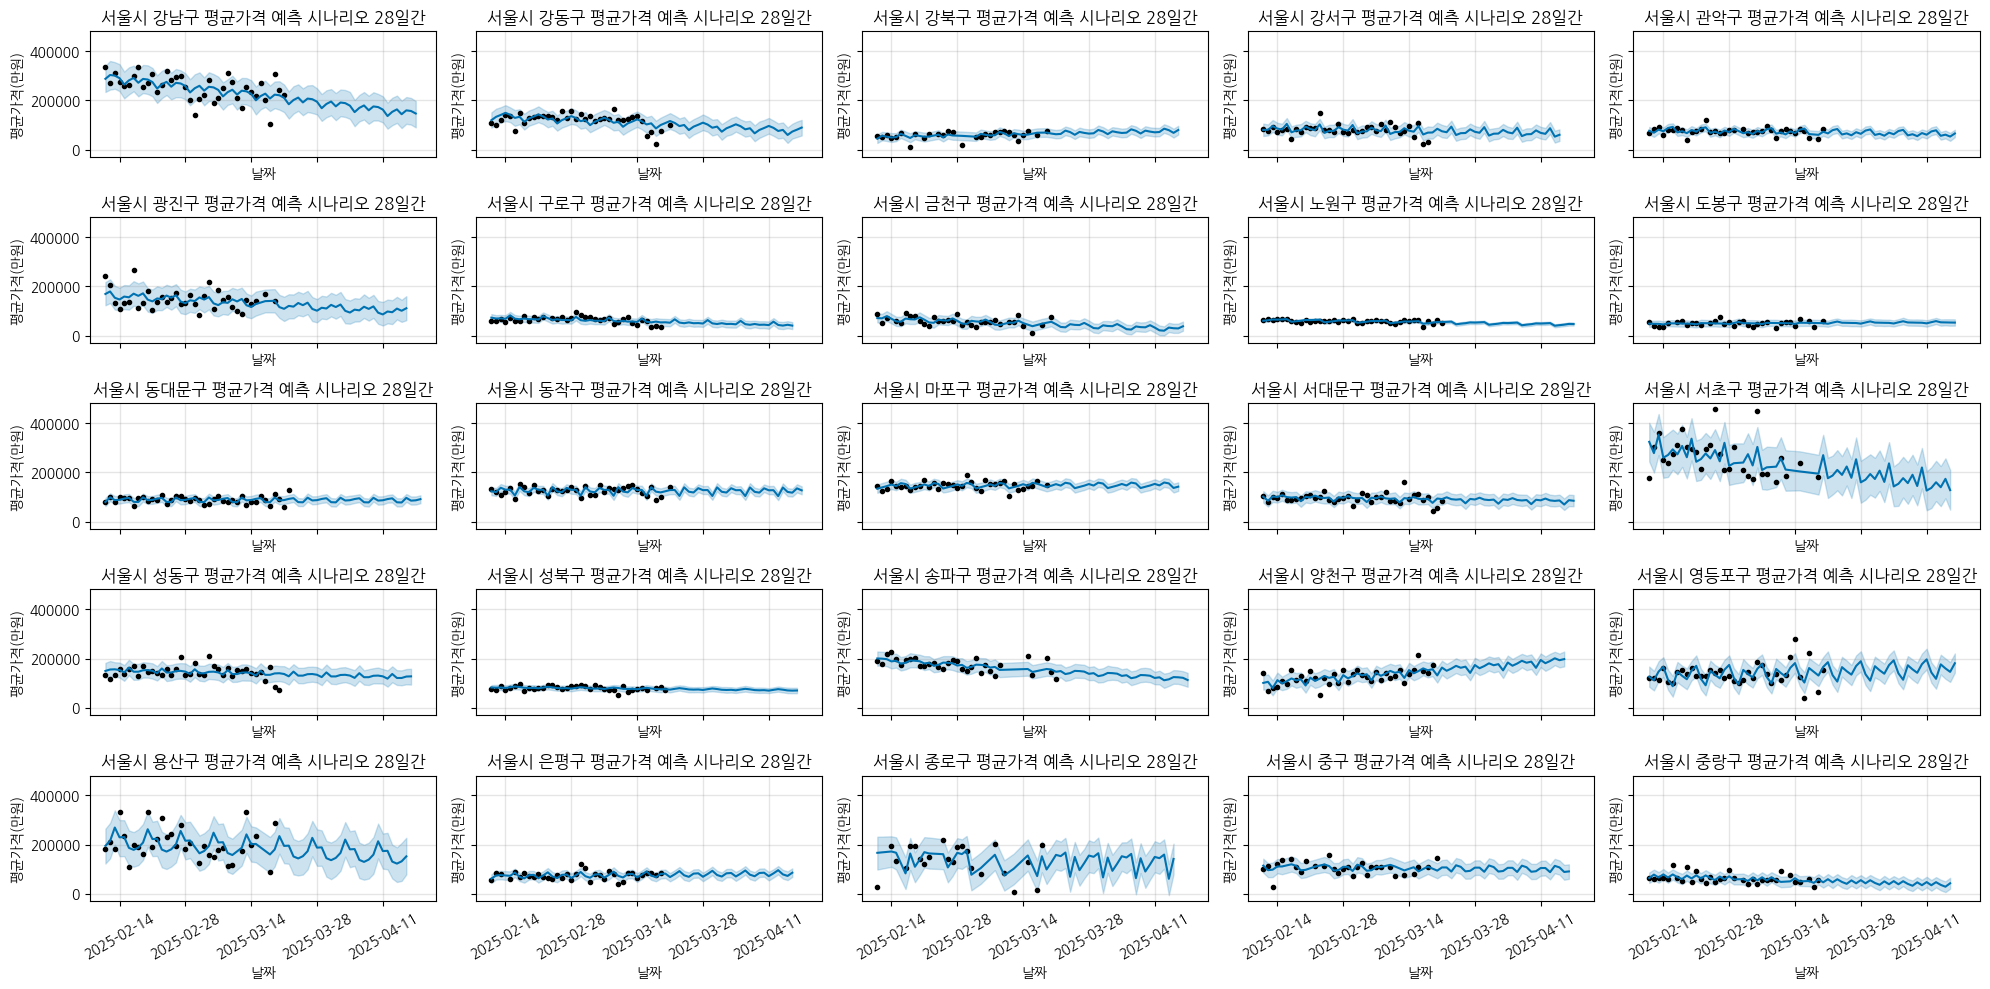

In [10]:
plt.rcParams['font.family'] = "NanumGothic"


periods = 28

fig, ax = plt.subplots(figsize=(20, 10), sharex=True, sharey=True, ncols=5, nrows=5)

for i in range(len(cgg_cds)):  
    future = models[i].make_future_dataframe(periods=periods)
    forecast = models[i].predict(future)

    row, col = divmod(i, 5) 
    models[i].plot(forecast, ax=ax[row, col], uncertainty=True)

    ax[row, col].set_title(f"서울시 {cgg_cds[i]} 평균가격 예측 시나리오 {periods}일간")
    ax[row, col].set_xlabel("날짜")
    ax[row, col].set_ylabel("평균가격(만원)")
    
    for tick in ax[row, col].get_xticklabels():
        tick.set_rotation(30)

plt.tight_layout()
plt.show()


In [ ]:
from prophet import Prophet
from prophet.serialize import model_to_json
import json

total_df = pd.read_csv('/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/data/seoul_real_estate.csv')
total_df["CTRT_DAY"] = pd.to_datetime(total_df["CTRT_DAY"], format="%Y-%m-%d")
total_df = total_df[total_df['BLDG_USG'] =='아파트']

cgg_nms = sorted(list(total_df['CGG_NM'].unique()))
periods = 28 # 향후 28일간 예측을 한다고 설정

for cgg_nm in cgg_nms:
    model = Prophet()
    total_df2 = total_df.loc[total_df['CGG_NM']==cgg_nm, ['CTRT_DAY', 'THING_AMT']]
    summary_df = total_df2.groupby('CTRT_DAY')['THING_AMT'].agg('mean').reset_index()
    summary_df = summary_df.rename(columns={'CTRT_DAY':'ds', 'THING_AMT':'y'})
    model.fit(summary_df)
                
    with open(f'/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/ml/model/{cgg_nm}.model.json', 'w') as fout:
        json.dump(model_to_json(model), fout)